# Week 2 — Feature Engineering (Bag-of-Words vs. TF-IDF)

**Project:** AI-Powered Fake News Detection Using Text Classification  
**Phase:** 2 of 4 (Days 8–14)  
**Notebook:** week2_feature_engineering.ipynb

This notebook covers:
- Loading the cleaned dataset (`data/processed/news_cleaned.csv`)
- Performing an 80/20 train/test split with a fixed random seed (`random_state=42`)
- Extracting features using Bag-of-Words (`CountVectorizer`)
- Extracting features using TF-IDF (`TfidfVectorizer` with `max_features=5000`)
- Analyzing vocabulary size, matrix sparsity, and dimensional stats
- Inspecting top-weighted terms across both classes
- Saving split data and vectorizers to disk for model building in Phase 3

In [1]:
import sys
import os
from pathlib import Path

# Ensure project root is on path
PROJECT_ROOT = Path(".").resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)
print(f"Working directory: {PROJECT_ROOT}")

Working directory: .


In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.utils import ensure_dirs
from src.features import get_bow_vectorizer, get_tfidf_vectorizer, fit_transform

ensure_dirs("data/processed", "results/figures", "results/metrics")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

## 1. Load Cleaned Dataset

In [3]:
data_path = Path("data/processed/news_cleaned.csv")
if not data_path.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found at {data_path}. Run week1_data_eda.ipynb first."
    )

df = pd.read_csv(data_path)
print(f"Loaded dataset: {len(df):,} rows")

# Ensure no missing values in clean_text (fill with empty string just in case)
df["clean_text"] = df["clean_text"].fillna("")

Loaded dataset: 39,098 rows


## 2. Train-Test Split

We split the dataset into an **80% training set** and a **20% test set**.  
To ensure reproducibility, we set `random_state=42` and stratify the split on the labels.

In [4]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train):,} ({100*len(X_train)/len(df):.1f}%)")
print(f"Test set size:     {len(X_test):,} ({100*len(X_test)/len(df):.1f}%)")

Training set size: 31,278 (80.0%)
Test set size:     7,820 (20.0%)


## 3. Feature Extraction — Bag-of-Words (Count Vectorization)

The CountVectorizer converts document text into a matrix of raw token frequencies (word counts).
We fit only on the training set to prevent data leakage from the test set.

In [5]:
bow_vec = get_bow_vectorizer(max_features=5000)
X_train_bow, X_test_bow, bow_vec = fit_transform(bow_vec, X_train, X_test)

print("Bag-of-Words Matrices:")
print(f"  Train shape: {X_train_bow.shape}")
print(f"  Test shape:  {X_test_bow.shape}")

Bag-of-Words Matrices:
  Train shape: (31278, 5000)
  Test shape:  (7820, 5000)


## 4. Feature Extraction — TF-IDF Vectorization

The TfidfVectorizer scales counts by how often terms appear across the corpus (down-weighting very common terms).  
We use `max_features=5000` to keep features matching the BoW baseline.

In [6]:
tfidf_vec = get_tfidf_vectorizer(max_features=5000)
X_train_tfidf, X_test_tfidf, tfidf_vec = fit_transform(tfidf_vec, X_train, X_test)

print("TF-IDF Matrices:")
print(f"  Train shape: {X_train_tfidf.shape}")
print(f"  Test shape:  {X_test_tfidf.shape}")

TF-IDF Matrices:
  Train shape: (31278, 5000)
  Test shape:  (7820, 5000)


## 5. Comparative Analysis (Sparsity & Dimensions)

In [7]:
def analyze_sparsity(matrix, name: str):
    total_elements = matrix.shape[0] * matrix.shape[1]
    non_zero_elements = matrix.nnz
    sparsity = 1.0 - (non_zero_elements / total_elements)
    print(f"{name} Sparsity:")
    print(f"  Non-zero elements: {non_zero_elements:,}")
    print(f"  Total cells:       {total_elements:,}")
    print(f"  Sparsity ratio:    {sparsity*100:.4f}%")
    return sparsity

bow_sparsity = analyze_sparsity(X_train_bow, "Bag-of-Words")
tfidf_sparsity = analyze_sparsity(X_train_tfidf, "TF-IDF")

Bag-of-Words Sparsity:
  Non-zero elements: 4,122,390
  Total cells:       156,390,000
  Sparsity ratio:    97.3640%
TF-IDF Sparsity:
  Non-zero elements: 4,122,390
  Total cells:       156,390,000
  Sparsity ratio:    97.3640%


## 6. Vocabulary Inspection & Feature Weights

Let's look at the terms with the highest mean TF-IDF weights across both classes (Fake vs. Real).

In [8]:
feature_names = np.array(tfidf_vec.get_feature_names_out())

def get_top_tfidf_terms(X_matrix, feature_names, labels, class_val, n=15):
    # Filter rows matching this class label
    class_indices = np.where(labels.values == class_val)[0]
    class_subset = X_matrix[class_indices]
    
    # Calculate mean TF-IDF weight for each feature column
    mean_weights = np.asarray(class_subset.mean(axis=0)).flatten()
    top_idx = mean_weights.argsort()[::-1][:n]
    
    return pd.DataFrame({
        "term": feature_names[top_idx],
        "weight": mean_weights[top_idx]
    })

# Find top 15 features in training set for each class
fake_top_tfidf = get_top_tfidf_terms(X_train_tfidf, feature_names, y_train, class_val=0)
real_top_tfidf = get_top_tfidf_terms(X_train_tfidf, feature_names, y_train, class_val=1)

print("=== Top 15 TF-IDF Terms in Fake News ===")
print(fake_top_tfidf.to_string(index=False))
print("\n=== Top 15 TF-IDF Terms in Real News ===")
print(real_top_tfidf.to_string(index=False))

=== Top 15 TF-IDF Terms in Fake News ===
     term   weight
    trump 0.089448
    video 0.033511
  clinton 0.027462
    obama 0.026695
   people 0.025525
  hillary 0.025115
president 0.023599
      one 0.021941
     like 0.021098
   donald 0.020600
     said 0.019996
    would 0.018419
  twitter 0.018214
      via 0.018013
    white 0.017409

=== Top 15 TF-IDF Terms in Real News ===
      term   weight
      said 0.066620
     trump 0.052127
   reuters 0.030441
 president 0.026945
     would 0.026032
     house 0.023974
     state 0.023507
government 0.021821
republican 0.020172
washington 0.018763
    united 0.018521
    states 0.018295
       new 0.018068
     north 0.017616
     party 0.017159


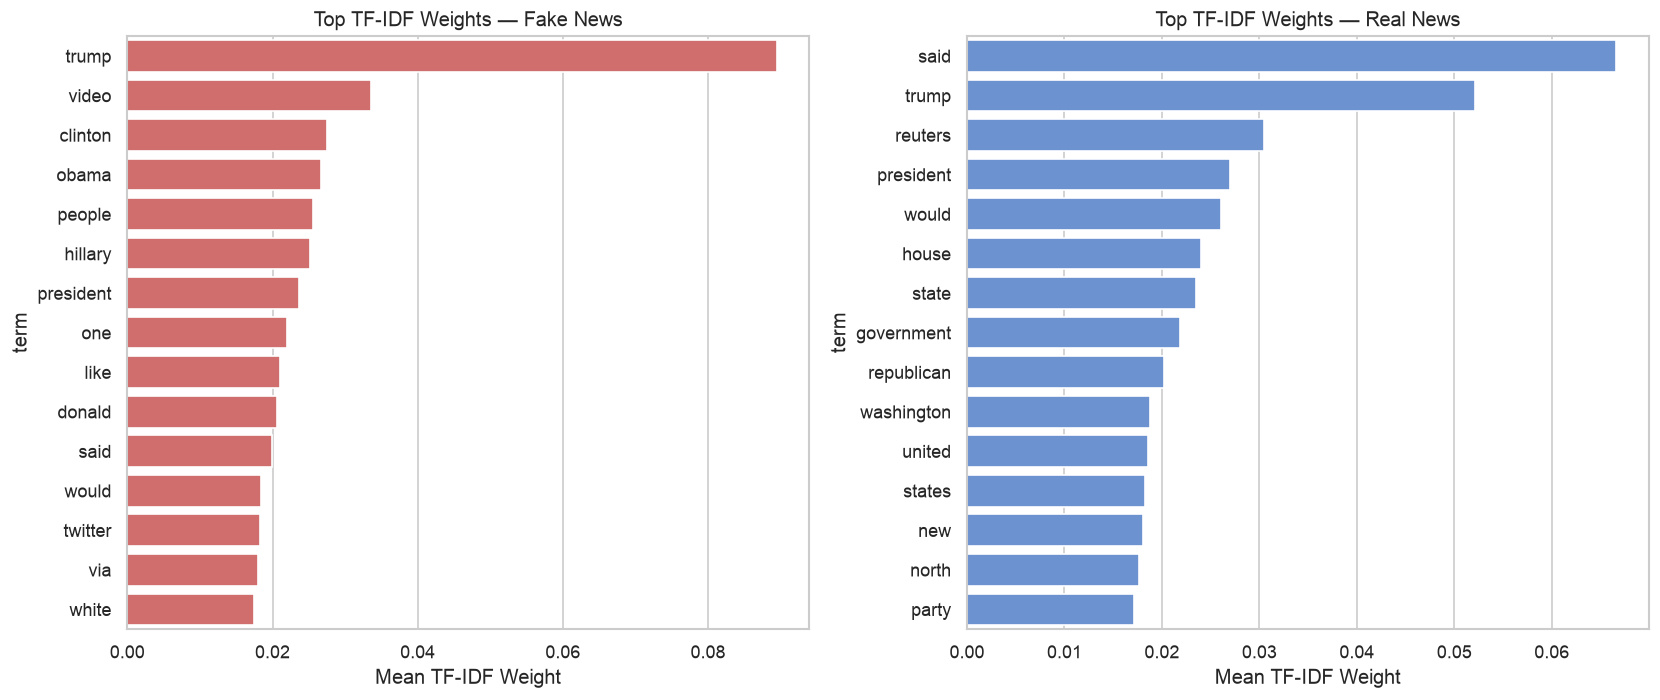

Saved: results/figures/top_tfidf_weights.png


In [9]:
# Visualising the top features per class side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=fake_top_tfidf, x="weight", y="term", ax=axes[0], color="#e05c5c")
axes[0].set_title("Top TF-IDF Weights — Fake News")
axes[0].set_xlabel("Mean TF-IDF Weight")

sns.barplot(data=real_top_tfidf, x="weight", y="term", ax=axes[1], color="#5c8ee0")
axes[1].set_title("Top TF-IDF Weights — Real News")
axes[1].set_xlabel("Mean TF-IDF Weight")

plt.tight_layout()
plt.savefig("results/figures/top_tfidf_weights.png", dpi=150)
plt.show()
print("Saved: results/figures/top_tfidf_weights.png")

## 7. Serialize Vectors and Split Sets

We save the split sets and fitted vectorizer objects so we can load them directly inside `week3_model_building.ipynb` without recalculating.

In [10]:
joblib.dump(y_train, "data/processed/y_train.joblib")
joblib.dump(y_test, "data/processed/y_test.joblib")

joblib.dump(X_train_bow, "data/processed/X_train_bow.joblib")
joblib.dump(X_test_bow, "data/processed/X_test_bow.joblib")
joblib.dump(bow_vec, "data/processed/bow_vectorizer.joblib")

joblib.dump(X_train_tfidf, "data/processed/X_train_tfidf.joblib")
joblib.dump(X_test_tfidf, "data/processed/X_test_tfidf.joblib")
joblib.dump(tfidf_vec, "data/processed/tfidf_vectorizer.joblib")

print("Saved all vectorized datasets and vectorizer models to data/processed/")

Saved all vectorized datasets and vectorizer models to data/processed/


## 8. Exporting Stats for the Phase 2 Report

In [11]:
stats = {
    "train_size": len(X_train),
    "test_size": len(X_test),
    "max_features": 5000,
    "bow_sparsity": round(bow_sparsity, 6),
    "tfidf_sparsity": round(tfidf_sparsity, 6)
}

with open("results/metrics/phase2_stats.joblib", "wb") as f:
    joblib.dump(stats, f)

print("Saved Phase 2 stats dictionary to results/metrics/phase2_stats.joblib")

Saved Phase 2 stats dictionary to results/metrics/phase2_stats.joblib
